# 🔩 Fine-tuning YOLOv8-seg — Detecção de Rachaduras
Notebook preparado para rodar no **Kaggle** com GPU T4.

In [5]:
# ── Verificação de ambiente ───────────────────────────────────────────
import os, subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else '⚠️  GPU não encontrada — ative em Settings > Accelerator > GPU T4 x2')


Sat May 30 18:36:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
# ── Instalação ───────────────────────────────────────────────────────
%pip install ultralytics -q
import ultralytics
ultralytics.checks()


Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6960.4/8062.4 GB disk)


In [7]:
# ── Parâmetros — EDITE AQUI ──────────────────────────────────────────
from pathlib import Path

# Pasta raiz onde estão suas imagens e rótulos
# No Kaggle, datasets ficam em /kaggle/input/<nome-do-dataset>/
DATASET_INPUT = Path('/kaggle/input/rachaduras')

# Onde as pastas organizadas serão criadas
DATASET_DIR   = Path('/kaggle/working/dataset')

# Nomes dos subdiretórios de imagens e rótulos dentro de DATASET_INPUT
# Ajuste se a estrutura for diferente
PASTA_IMGS = Path('/kaggle/input/datasets/fredstrey/rachaduras/images')
PASTA_TXTS = Path('/kaggle/input/datasets/fredstrey/rachaduras/labels')

# Split
SPLIT_VAL  = 0.10  # 10% validação
SPLIT_TEST = 0.10  # 10% teste

# Modelo base — opções: yolov8n-seg, yolov8s-seg, yolov8m-seg
# n = mais rápido/leve | m = mais preciso/pesado
MODELO_BASE = 'yolov8s-seg.pt'

# Treinamento
EPOCHS   = 100
IMGSZ    = 640
BATCH    = 16          # reduza pra 8 se der OOM
PATIENCE = 20          # early stopping: para se não melhorar em N épocas

# Classes
NOMES_CLASSES = ['rachadura']


## 📂 Etapa 1 — Organizar dataset em estrutura YOLO

In [8]:
import shutil, random
from pathlib import Path

extensoes_img = ('.jpg', '.jpeg', '.png', '.bmp')

# Coleta todas as imagens que têm um .txt correspondente
imagens = sorted([
    p for p in PASTA_IMGS.rglob('*')
    if p.suffix.lower() in extensoes_img
    and (PASTA_TXTS / p.with_suffix('.txt').name).exists()
])

print(f'Total de pares imagem+rótulo encontrados: {len(imagens)}')

random.seed(42)
random.shuffle(imagens)

n       = len(imagens)
n_val   = int(n * SPLIT_VAL)
n_test  = int(n * SPLIT_TEST)

splits = {
    'val':   imagens[:n_val],
    'test':  imagens[n_val:n_val + n_test],
    'train': imagens[n_val + n_test:],
}

for split, arquivos in splits.items():
    (DATASET_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)
    for img in arquivos:
        txt = PASTA_TXTS / img.with_suffix('.txt').name
        shutil.copy(img, DATASET_DIR / 'images' / split / img.name)
        shutil.copy(txt, DATASET_DIR / 'labels' / split / txt.name)
    print(f'  {split:>5}: {len(arquivos)} imagens')

print('\n✅ Dataset organizado.')


Total de pares imagem+rótulo encontrados: 1551
    val: 155 imagens
   test: 155 imagens
  train: 1241 imagens

✅ Dataset organizado.


## 📝 Etapa 2 — Criar dataset.yaml

In [9]:
yaml_content = f"""path: {DATASET_DIR}
train: images/train
val:   images/val
test:  images/test

nc: {len(NOMES_CLASSES)}
names: {NOMES_CLASSES}
"""

yaml_path = DATASET_DIR / 'dataset.yaml'
yaml_path.write_text(yaml_content)
print(yaml_path.read_text())


path: /kaggle/working/dataset
train: images/train
val:   images/val
test:  images/test

nc: 1
names: ['rachadura']



## 🚀 Etapa 3 — Fine-tuning

In [10]:
from ultralytics import YOLO

model = YOLO(MODELO_BASE)

results = model.train(
    data=str(yaml_path),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    patience=PATIENCE,
    device=0,              # GPU 0; use 'cpu' se necessário
    workers=2,             # Kaggle suporta poucos workers
    project='/kaggle/working/runs',
    name='rachadura_seg',
    exist_ok=True,
    augment=True,          # augmentação automática — importante com dataset pequeno
    degrees=15.0,          # rotação aleatória ±15°
    flipud=0.3,            # flip vertical 30% das vezes
    mosaic=1.0,            # mosaico — combina 4 imagens em 1
    close_mosaic=10,       # desliga mosaico nas últimas 10 épocas
    verbose=True,
)

print('\n✅ Treinamento concluído.')
print(f'Melhor checkpoint: {results.save_dir}/weights/best.pt')


Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/dataset.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rachadura_seg, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

## 📊 Etapa 4 — Métricas de validação

In [11]:
# Avalia no conjunto de teste com o melhor checkpoint
best_pt = Path('/kaggle/working/runs/rachadura_seg/weights/best.pt')
model_eval = YOLO(str(best_pt))

metrics = model_eval.val(
    data=str(yaml_path),
    split='test',
    imgsz=IMGSZ,
    device=0,
)

print(f'mAP50      (box): {metrics.box.map50:.4f}')
print(f'mAP50-95   (box): {metrics.box.map:.4f}')
print(f'mAP50     (mask): {metrics.seg.map50:.4f}')
print(f'mAP50-95  (mask): {metrics.seg.map:.4f}')


Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3200.7±1037.6 MB/s, size: 704.1 KB)
val: Scanning /kaggle/working/dataset/labels/test... 155 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 155/155 822.4it/s 0.2s3s
val: New cache created: /kaggle/working/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.6it/s 3.9s.2ss
                   all        155        200      0.768       0.76      0.818      0.633      0.774       0.66      0.728      0.276
Speed: 1.9ms preprocess, 6.9ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to /kaggle/working/runs/segment/val
mAP50      (box): 0.8176
mAP50-95   (box): 0.6335
mAP50     (mask): 0.7283
mAP50-95  (mask): 0.2761


## 🖼️ Etapa 5 — Inferência visual nas imagens de teste


0: 384x640 1 rachadura, 11.1ms
1: 384x640 1 rachadura, 11.1ms
2: 384x640 1 rachadura, 11.1ms
3: 384x640 2 rachaduras, 11.1ms
4: 384x640 1 rachadura, 11.1ms
5: 384x640 1 rachadura, 11.1ms
Speed: 2.1ms preprocess, 11.1ms inference, 3.8ms postprocess per image at shape (1, 3, 384, 640)


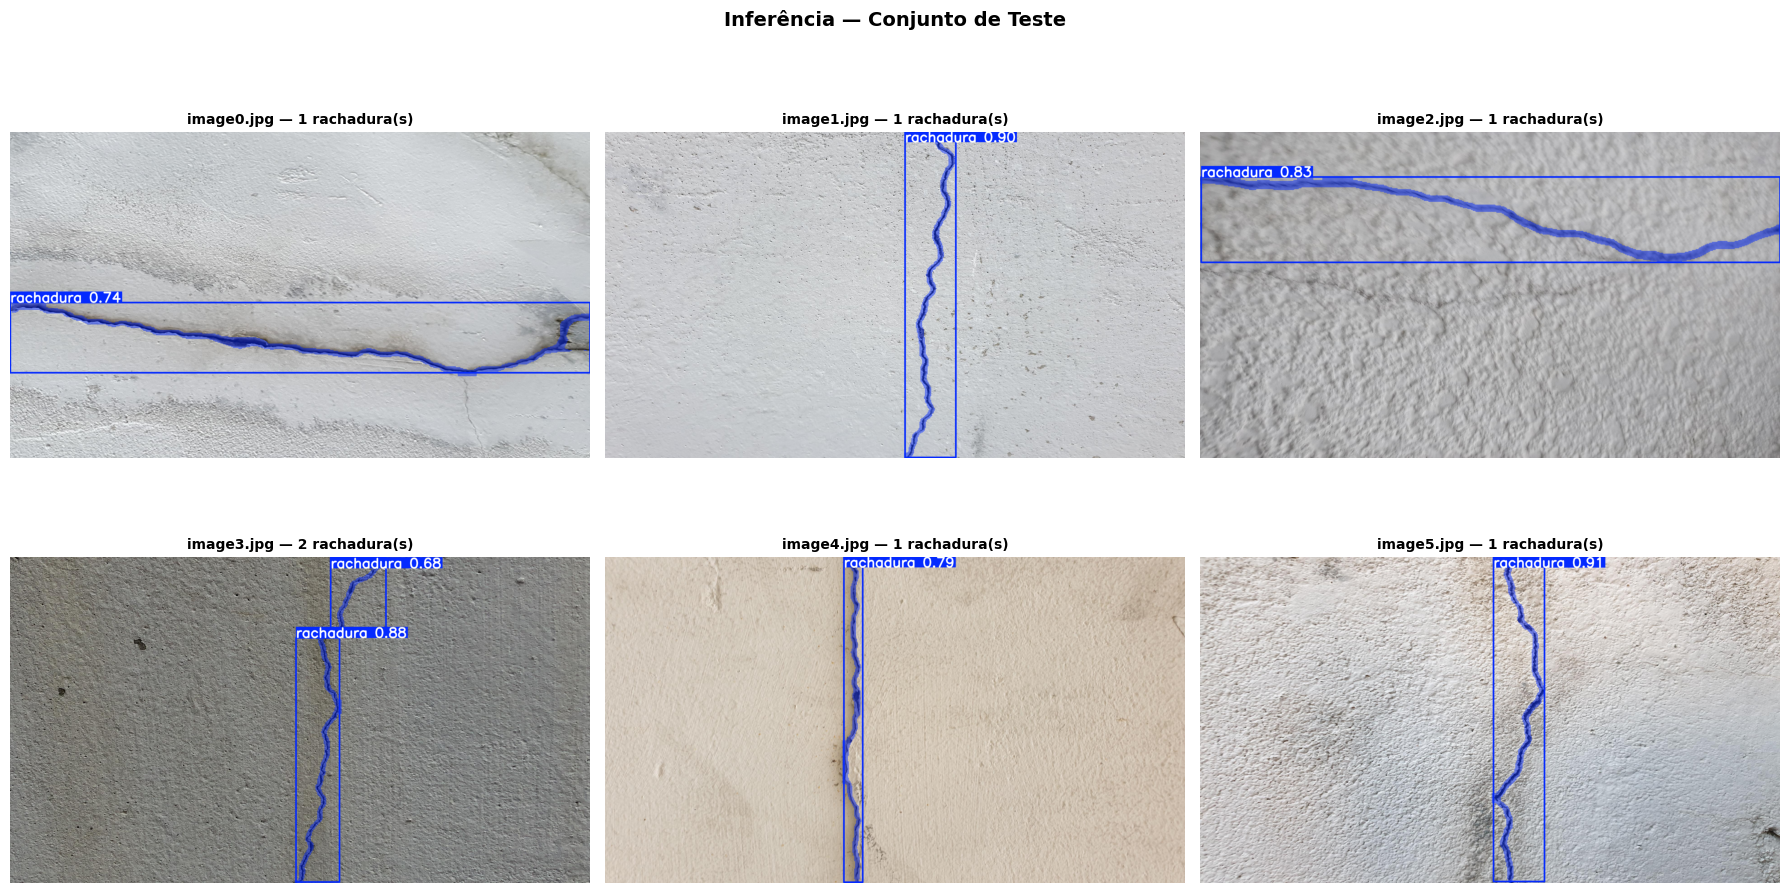

✅ Salvo em /kaggle/working/inferencia_teste.png


In [12]:
import cv2
import matplotlib.pyplot as plt
import random

test_imgs = list((DATASET_DIR / 'images' / 'test').glob('*'))
amostras  = random.sample(test_imgs, min(6, len(test_imgs)))

results_vis = model_eval.predict(
    source=amostras,
    imgsz=IMGSZ,
    conf=0.25,
    device=0,
    save=False,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, r in zip(axes, results_vis):
    img_plot = r.plot()                          # BGR com máscaras desenhadas
    img_plot = cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB)
    n_det = len(r.boxes) if r.boxes is not None else 0
    ax.imshow(img_plot)
    ax.set_title(f'{Path(r.path).name} — {n_det} rachadura(s)', fontsize=10, fontweight='bold')
    ax.axis('off')

for ax in axes[len(results_vis):]:
    ax.axis('off')

plt.suptitle('Inferência — Conjunto de Teste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/inferencia_teste.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Salvo em /kaggle/working/inferencia_teste.png')


## 💾 Etapa 6 — Exportar modelo

In [13]:
# Exporta pra ONNX (portável, roda sem ultralytics instalado)
model_eval.export(format='onnx', imgsz=IMGSZ, dynamic=True)
print('✅ Modelo exportado para ONNX')

# O best.pt original também fica disponível para download
print(f'\nArquivos para download:')
print(f'  PyTorch : {best_pt}')
print(f'  ONNX    : {str(best_pt).replace(".pt", ".onnx")}')


Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/rachadura_seg/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 37, 8400), (1, 32, 160, 160)) (22.7 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.82', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 342ms
Prepared 2 packages in 337ms
Installed 2 packages in 13ms
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 4.6s, saved as '/kaggle/working/runs/rachadura_seg/weights/best.on